In [ ]:
import kagglehub

# Download latest version

path = kagglehub.dataset_download("jessicali9530/caltech256")
print("Path to dataset files:", path)

100%|██████████| 2.12G/2.12G [00:18<00:00, 120MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/caltech256/versions/2


In [ ]:
import os

def find_class_folders(root_path: str):
    """Kök dizinde, doğrudan görüntü dosyaları barındıran alt klasörleri
    (sınıf klasörlerini) otomatik bulur - Kaggle veri setleri farklı
    derinliklerde klasörleme yapabildiği için kör bir sabit yol
    varsaymak yerine dizini tarıyoruz.
    """
    for current_dir, subdirs, files in os.walk(root_path):
        image_files = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        if image_files and len(subdirs) == 0:
            return os.path.dirname(current_dir)
    return root_path


VERI_KOK_DIZIN = find_class_folders(path)
sinif_isimleri = sorted([
    d for d in os.listdir(VERI_KOK_DIZIN)
    if os.path.isdir(os.path.join(VERI_KOK_DIZIN, d))
])

print(f"Veri kök dizini bulundu: {VERI_KOK_DIZIN}")
print(f"Toplam sınıf sayısı: {len(sinif_isimleri)}")
print(f"İlk 5 sınıf: {sinif_isimleri[:5]}")

Veri kök dizini bulundu: /root/.cache/kagglehub/datasets/jessicali9530/caltech256/versions/2/256_ObjectCategories
Toplam sınıf sayısı: 257
İlk 5 sınıf: ['001.ak47', '002.american-flag', '003.backpack', '004.baseball-bat', '005.baseball-glove']


In [ ]:
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import torch

MODEL_ADI = "openai/clip-vit-large-patch14"
model = CLIPModel.from_pretrained(MODEL_ADI)
processor = CLIPProcessor.from_pretrained(MODEL_ADI)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()


def get_image_embedding(image_path: str) -> torch.Tensor:
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        vision_outputs = model.vision_model(**inputs)
        embedding = model.visual_projection(vision_outputs.pooler_output)
    return embedding.squeeze(0).cpu()

print(f"CLIP hazır, cihaz: {device}")

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP hazır, cihaz: cuda


In [ ]:
import random

MAX_ORNEK_SINIF_BASINA = 50
random.seed(42)

X, y = [], []

for sinif_idx, sinif_adi in enumerate(sinif_isimleri):
    sinif_klasoru = os.path.join(VERI_KOK_DIZIN, sinif_adi)
    dosyalar = [f for f in os.listdir(sinif_klasoru) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(dosyalar)
    dosyalar = dosyalar[:MAX_ORNEK_SINIF_BASINA]

    for dosya in dosyalar:
        try:
            emb = get_image_embedding(os.path.join(sinif_klasoru, dosya))
            X.append(emb)
            y.append(sinif_idx)
        except Exception:
            pass

    if sinif_idx % 40 == 0:
        print(f"{sinif_idx}/{len(sinif_isimleri)} sınıf işlendi...")

X = torch.stack(X)
y = torch.tensor(y)
print(f"\nToplam örnek: {X.shape[0]}, embedding boyutu: {X.shape[1]}")

0/257 sınıf işlendi...
40/257 sınıf işlendi...
80/257 sınıf işlendi...
120/257 sınıf işlendi...
160/257 sınıf işlendi...
200/257 sınıf işlendi...
240/257 sınıf işlendi...

Toplam örnek: 12850, embedding boyutu: 768


In [ ]:
from sklearn.model_selection import train_test_split

X_np, y_np = X.numpy(), y.numpy()

X_temp, X_test, y_temp, y_test = train_test_split(X_np, y_np, test_size=0.15, random_state=42, stratify=y_np)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

X_train, X_val, X_test = map(torch.tensor, (X_train, X_val, X_test))
y_train, y_val, y_test = map(torch.tensor, (y_train, y_val, y_test))

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 8999, Val: 1923, Test: 1928


In [ ]:
import torch.nn as nn
import torch.optim as optim

class MLPHead(nn.Module):
    def __init__(self, embedding_dim, num_classes, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


embedding_dim = X.shape[1]
num_classes = len(sinif_isimleri)
head_model = MLPHead(embedding_dim, num_classes).to(device)

optimizer = optim.Adam(head_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

X_train_d, y_train_d = X_train.to(device), y_train.to(device)
X_val_d, y_val_d = X_val.to(device), y_val.to(device)

EPOCHS = 60
en_iyi_val_loss = float("inf")
en_iyi_agirliklar = None
sabir, sayac = 8, 0
egitim_gecmisi = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    head_model.train()
    optimizer.zero_grad()
    outputs = head_model(X_train_d)
    loss = criterion(outputs, y_train_d)
    loss.backward()
    optimizer.step()

    head_model.eval()
    with torch.no_grad():
        val_outputs = head_model(X_val_d)
        val_loss = criterion(val_outputs, y_val_d)
        val_acc = (val_outputs.argmax(dim=1) == y_val_d).float().mean().item()

    egitim_gecmisi["train_loss"].append(loss.item())
    egitim_gecmisi["val_loss"].append(val_loss.item())
    egitim_gecmisi["val_acc"].append(val_acc)

    if val_loss.item() < en_iyi_val_loss:
        en_iyi_val_loss = val_loss.item()
        en_iyi_agirliklar = {k: v.clone() for k, v in head_model.state_dict().items()}
        sayac = 0
    else:
        sayac += 1

    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch}: train_loss={loss.item():.4f}, val_loss={val_loss.item():.4f}, val_acc={val_acc:.2%}")

    if sayac >= sabir:
        print(f"Erken durdurma: epoch {epoch}")
        break

head_model.load_state_dict(en_iyi_agirliklar)
print(f"\nEn iyi val_loss: {en_iyi_val_loss:.4f}")

Epoch 0: train_loss=5.5640, val_loss=5.4439, val_acc=2.65%
Epoch 5: train_loss=4.8381, val_loss=4.6731, val_acc=76.03%
Epoch 10: train_loss=3.7406, val_loss=3.5419, val_acc=87.05%
Epoch 15: train_loss=2.4867, val_loss=2.2935, val_acc=90.17%
Epoch 20: train_loss=1.3888, val_loss=1.2551, val_acc=92.93%
Epoch 25: train_loss=0.7192, val_loss=0.6705, val_acc=93.97%
Epoch 30: train_loss=0.4060, val_loss=0.4099, val_acc=94.54%
Epoch 35: train_loss=0.2649, val_loss=0.2955, val_acc=94.85%
Epoch 40: train_loss=0.1889, val_loss=0.2400, val_acc=95.22%
Epoch 45: train_loss=0.1454, val_loss=0.2094, val_acc=95.58%
Epoch 50: train_loss=0.1134, val_loss=0.1923, val_acc=95.58%
Epoch 55: train_loss=0.0918, val_loss=0.1807, val_acc=95.74%
Epoch 59: train_loss=0.0765, val_loss=0.1751, val_acc=95.94%

En iyi val_loss: 0.1751


NİHAİ TEST DOĞRULUĞU: 94.71%

                               precision    recall  f1-score   support

                     001.ak47       0.88      1.00      0.93         7
            002.american-flag       1.00      1.00      1.00         8
                 003.backpack       1.00      0.57      0.73         7
             004.baseball-bat       1.00      0.88      0.93         8
           005.baseball-glove       1.00      1.00      1.00         8
          006.basketball-hoop       1.00      1.00      1.00         7
                      007.bat       1.00      1.00      1.00         7
                  008.bathtub       1.00      0.88      0.93         8
                     009.bear       1.00      1.00      1.00         8
                 010.beer-mug       1.00      0.86      0.92         7
                011.billiards       1.00      1.00      1.00         7
               012.binoculars       1.00      1.00      1.00         8
                 013.birdbath       0.88      

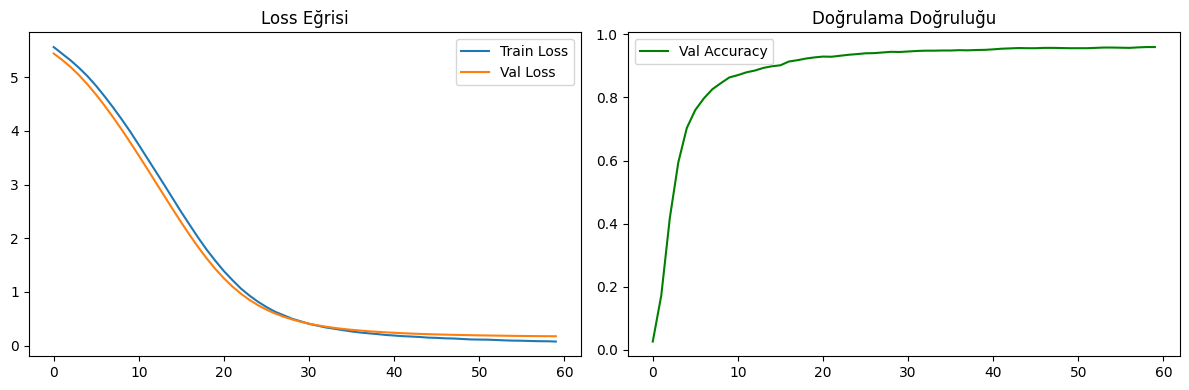

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Tüm dosyalar kaydedildi ve indirildi.


In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import json

head_model.eval()
X_test_d, y_test_d = X_test.to(device), y_test.to(device)
with torch.no_grad():
    test_preds = head_model(X_test_d).argmax(dim=1).cpu()

test_acc = (test_preds == y_test).float().mean().item()
print(f"NİHAİ TEST DOĞRULUĞU: {test_acc:.2%}\n")
print(classification_report(y_test.numpy(), test_preds.numpy(), target_names=sinif_isimleri, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(egitim_gecmisi["train_loss"], label="Train Loss")
axes[0].plot(egitim_gecmisi["val_loss"], label="Val Loss")
axes[0].set_title("Loss Eğrisi"); axes[0].legend()
axes[1].plot(egitim_gecmisi["val_acc"], label="Val Accuracy", color="green")
axes[1].set_title("Doğrulama Doğruluğu"); axes[1].legend()
plt.tight_layout()
plt.savefig("egitim_grafikleri.png", dpi=150)
plt.show()

torch.save(head_model.state_dict(), "linear_head_weights.pth")
with open("class_names.json", "w", encoding="utf-8") as f:
    json.dump(sinif_isimleri, f, ensure_ascii=False, indent=2)
with open("egitim_ozeti.json", "w", encoding="utf-8") as f:
    json.dump({
        "num_classes": num_classes, "embedding_dim": embedding_dim,
        "test_accuracy": test_acc, "final_val_accuracy": egitim_gecmisi["val_acc"][-1],
    }, f, ensure_ascii=False, indent=2)

from google.colab import files
files.download("linear_head_weights.pth")
files.download("class_names.json")
files.download("egitim_ozeti.json")
files.download("egitim_grafikleri.png")

print("\nTüm dosyalar kaydedildi ve indirildi.")

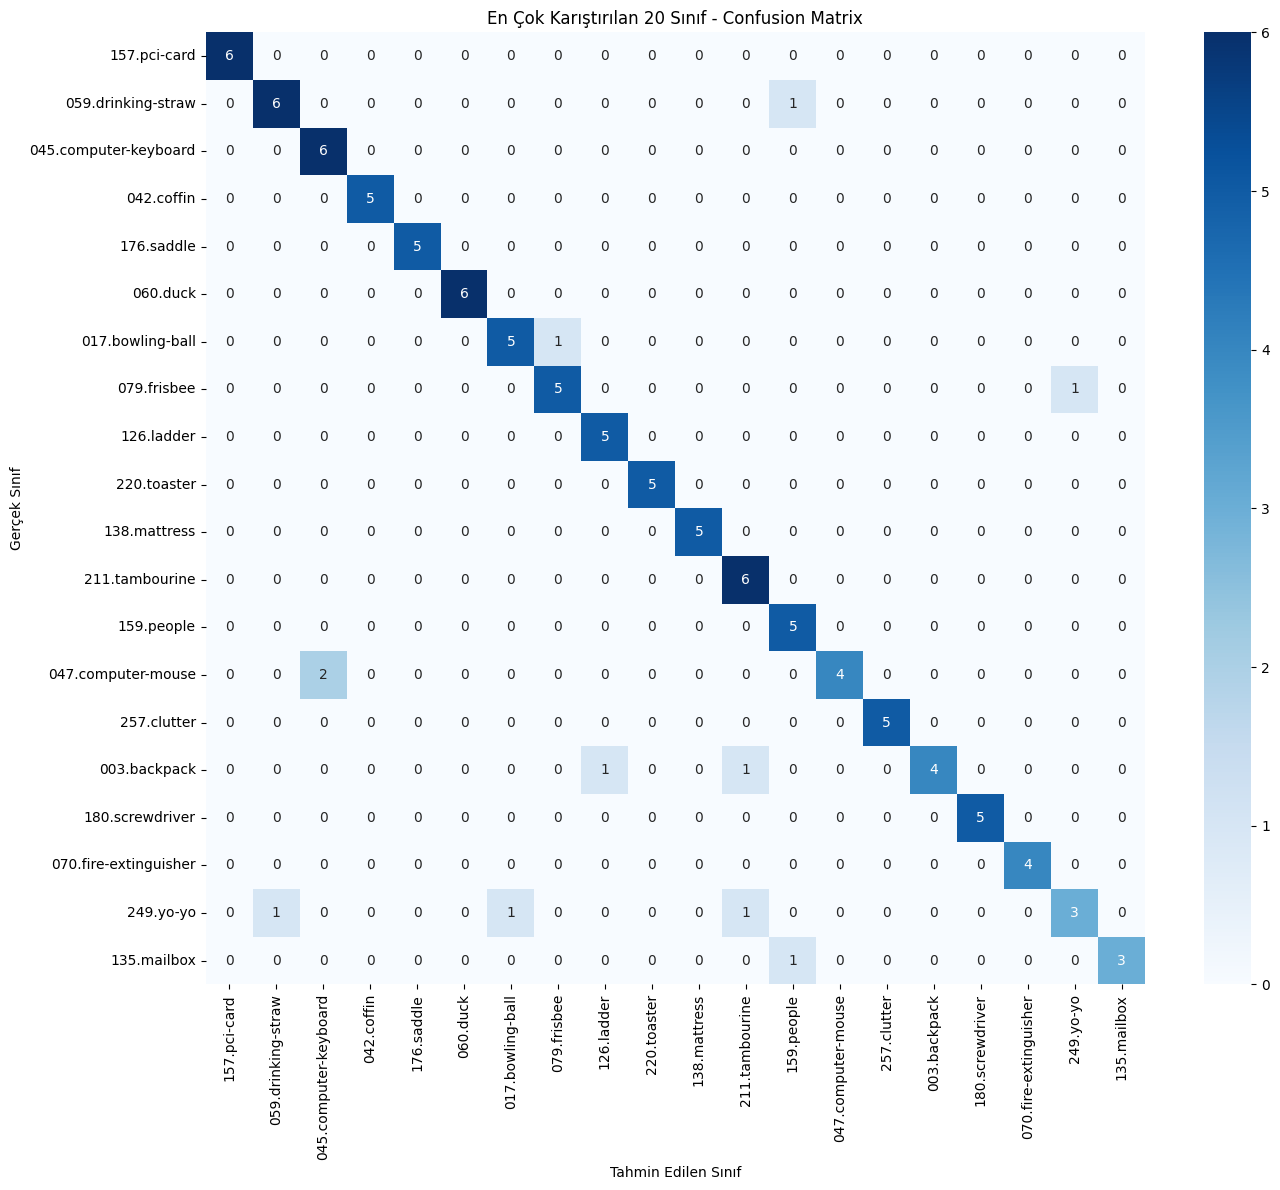

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Confusion matrix oluşturuldu ve kaydedildi.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

X_test_d = X_test.to(device)
head_model.eval()
with torch.no_grad():
    test_preds = head_model(X_test_d).argmax(dim=1).cpu().numpy()

y_test_np = y_test.numpy()

cm = confusion_matrix(y_test_np, test_preds)

# 257 sınıf tek bir ısı haritasına sığmaz, en çok karıştırılan (köşegen
# dışında en yüksek toplam hataya sahip) ilk 20 sınıfı bulup sadece
# onları gösteriyoruz - okunabilirlik için.
yanlislar = cm.copy()
np.fill_diagonal(yanlislar, 0)
en_cok_karisan_siniflar = np.argsort(yanlislar.sum(axis=1))[-20:]

cm_alt_kume = cm[np.ix_(en_cok_karisan_siniflar, en_cok_karisan_siniflar)]
etiketler = [sinif_isimleri[i] for i in en_cok_karisan_siniflar]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_alt_kume, annot=True, fmt="d", xticklabels=etiketler, yticklabels=etiketler, cmap="Blues")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("En Çok Karıştırılan 20 Sınıf - Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Tahminleri de ayrıca kaydediyoruz - bağlantı tekrar koparsa bu analiz kaybolmasın.
np.save("test_predictions.npy", test_preds)
np.save("test_labels.npy", y_test_np)

from google.colab import files
files.download("confusion_matrix.png")
files.download("test_predictions.npy")
files.download("test_labels.npy")

print("Confusion matrix oluşturuldu ve kaydedildi.")

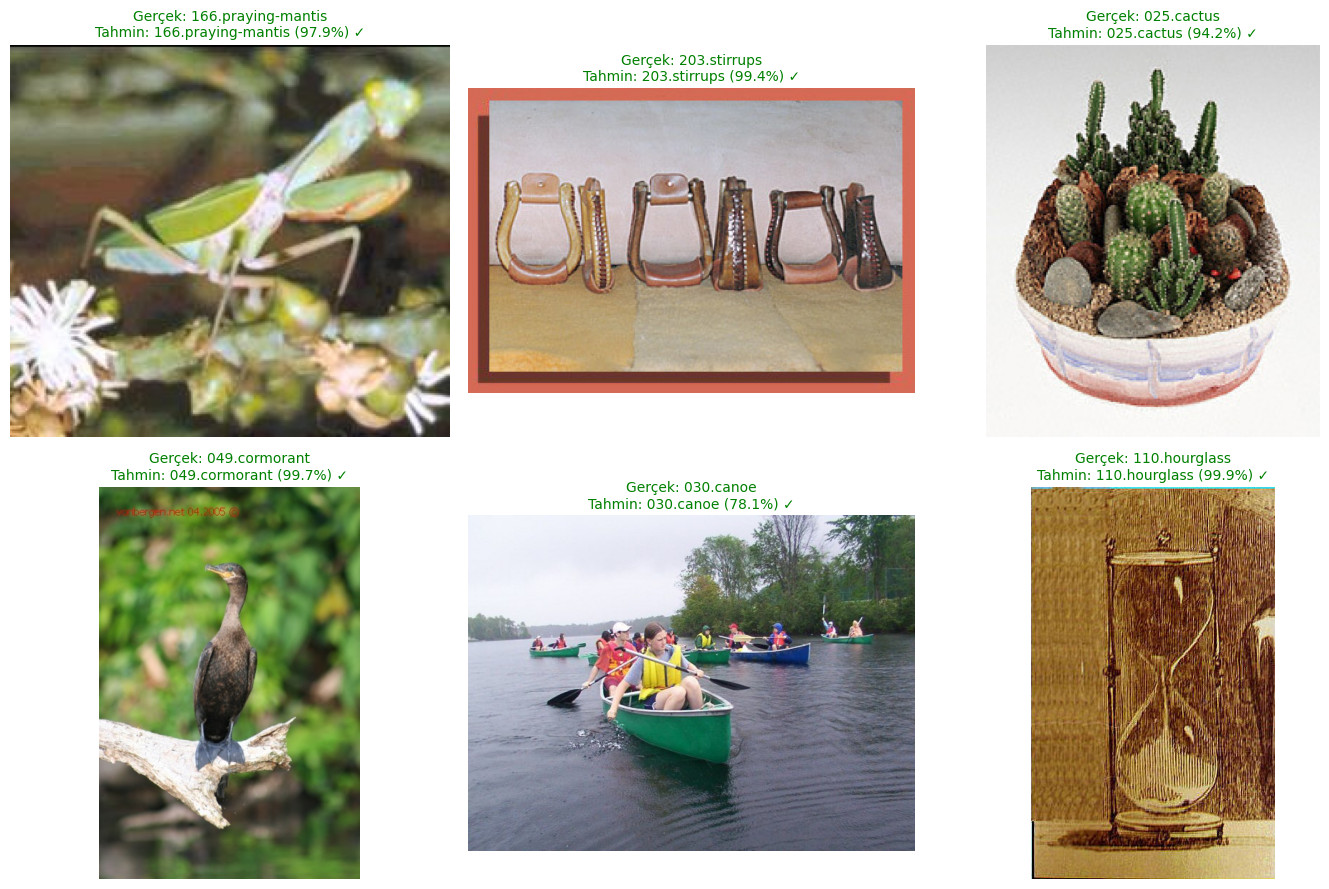

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import random

random.seed(7)  # Farklı örnekler görmek istersen bu sayıyı değiştir

secilen_orneklerin_bilgisi = []
for _ in range(6):
    sinif_idx = random.randint(0, len(sinif_isimleri) - 1)
    sinif_adi = sinif_isimleri[sinif_idx]
    sinif_klasoru = os.path.join(VERI_KOK_DIZIN, sinif_adi)
    dosyalar = [f for f in os.listdir(sinif_klasoru) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    secilen_dosya = random.choice(dosyalar)
    secilen_orneklerin_bilgisi.append((sinif_adi, os.path.join(sinif_klasoru, secilen_dosya)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, (gercek_sinif, dosya_yolu) in zip(axes.flat, secilen_orneklerin_bilgisi):
    img = Image.open(dosya_yolu).convert("RGB")
    emb = get_image_embedding(dosya_yolu).unsqueeze(0).to(device)

    head_model.eval()
    with torch.no_grad():
        cikti = head_model(emb)
        tahmin_idx = cikti.argmax(dim=1).item()
        guven = cikti.softmax(dim=1)[0, tahmin_idx].item()

    tahmin_sinif = sinif_isimleri[tahmin_idx]
    dogru_mu = "✓" if tahmin_sinif == gercek_sinif else "✗"
    renk = "green" if tahmin_sinif == gercek_sinif else "red"

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Gerçek: {gercek_sinif}\nTahmin: {tahmin_sinif} ({guven:.1%}) {dogru_mu}", fontsize=10, color=renk)

plt.tight_layout()
plt.savefig("ornek_tahminler.png", dpi=150)
plt.show()

from google.colab import files
files.download("ornek_tahminler.png")

In [ ]:
import json

egitim_ozeti_detayli = {
    "num_classes": num_classes,
    "embedding_dim": embedding_dim,
    "model_mimarisi": "CLIP ViT-L/14 (dondurulmuş) + MLPHead (768 -> 512 -> 257)",
    "hiperparametreler": {
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "dropout": 0.2,
        "optimizer": "Adam",
        "max_epochs": 60,
        "early_stopping_patience": 8,
        "train_test_split": "70/15/15 (stratified)",
        "sinif_basina_max_ornek": 50,
    },
    "sonuclar": {
        "test_accuracy": 0.9471,
        "final_val_accuracy": egitim_gecmisi["val_acc"][-1],
        "final_val_loss": en_iyi_val_loss,
    },
}

with open("egitim_ozeti.json", "w", encoding="utf-8") as f:
    json.dump(egitim_ozeti_detayli, f, ensure_ascii=False, indent=2)

from google.colab import files
files.download("egitim_ozeti.json")
print("Eğitim özeti hiperparametrelerle güncellendi.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Eğitim özeti hiperparametrelerle güncellendi.
